# PyTorch Datasets and DataLoaders: A Comprehensive Guide

In [6]:
# Import essential libraries
import torch
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.9.0+cpu
Device available: cpu


## 1. Understanding the Basics: Dataset vs DataLoader

In [7]:
# The Dataset class defines what data we have to hold. In this case random. But this could be Sentinel2 images or Traffic signs
class SimpleDataset(Dataset):
    def __init__(self, size=100):
        
        self.data = torch.randn(size, 10) 
        self.labels = torch.randint(0, 3, (size,))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Create dataset
simple_dataset = SimpleDataset(size=100)
print(f"Dataset length: {len(simple_dataset)}")
print(f"Sample shape: {simple_dataset[0][0].shape}")

Dataset length: 100
Sample shape: torch.Size([10])


In [8]:
simple_loader = DataLoader(
    simple_dataset,
    # the batch size is one important parameter you have to set. A lower batchsize implies more 
    batch_size=16,
    shuffle=True,
    num_workers=0
)

print(f"DataLoader length (number of batches): {len(simple_loader)}")

# Get one batch
batch_data, batch_labels = next(iter(simple_loader))
print(f"Batch data shape: {batch_data.shape}")
print(f"Batch labels shape: {batch_labels.shape}")
print(f"Batch labels: {batch_labels}")

DataLoader length (number of batches): 7
Batch data shape: torch.Size([16, 10])
Batch labels shape: torch.Size([16])
Batch labels: tensor([1, 2, 0, 2, 0, 0, 1, 2, 1, 1, 0, 2, 2, 2, 1, 0])


In [9]:
for data, labels in simple_loader:
    print(data.device)
    #data = data.to("cuda:0")
    print(data.device)
    break

cpu
cpu


## 2. Built-in Datasets: MNIST Example

In [11]:
from torchvision import datasets, transforms

# Define basic transforms
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST statistics
])

# Download and load MNIST
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,  
    transform=transform
)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 279kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]

Training set size: 60000
Test set size: 10000
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [12]:
# Examine a single sample
sample_image, sample_label = train_dataset[0]
print(f"Image shape: {sample_image.shape}")

Image shape: torch.Size([1, 28, 28])


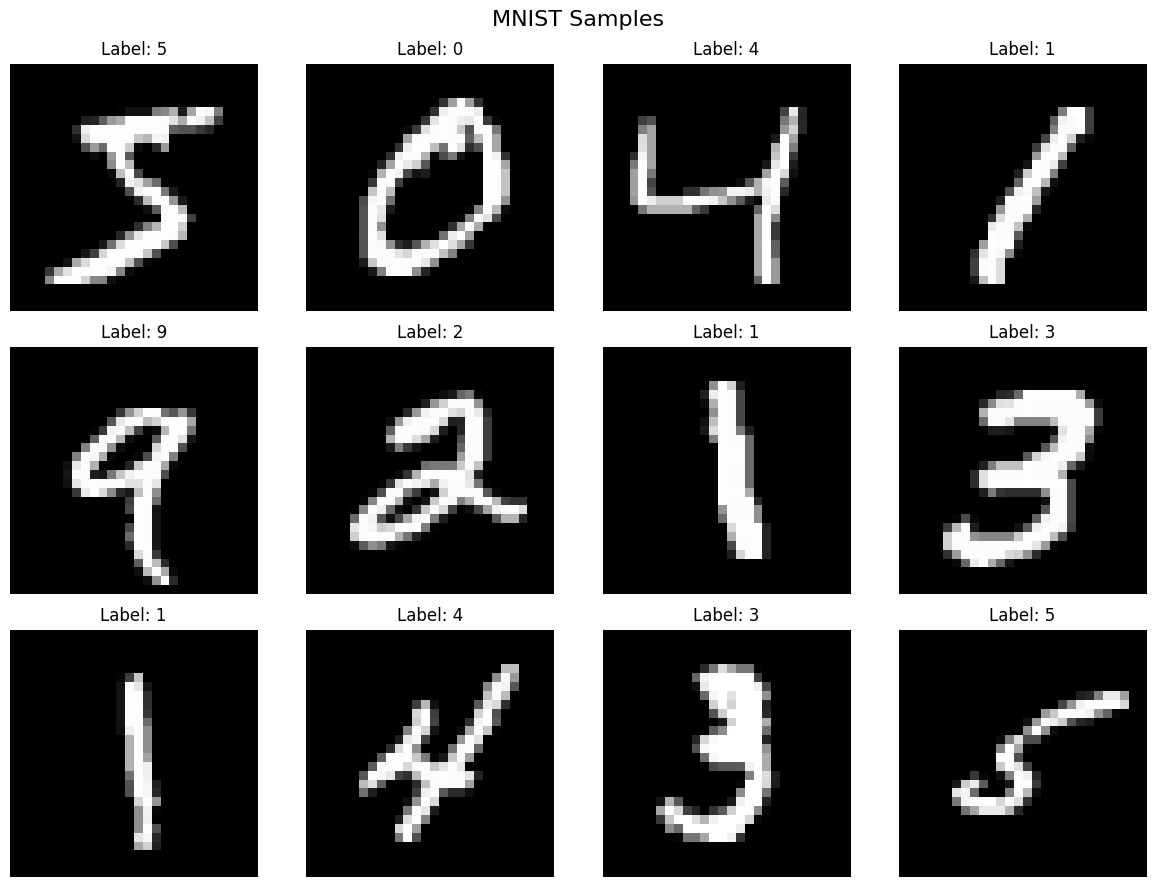

In [13]:
# Visualize some MNIST samples
def visualize_samples(dataset, num_samples=12, title="MNIST Samples"):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()
    
    for i in range(num_samples):
        image, label = dataset[i]
        # Convert from tensor to numpy and handle normalization
        img = image.squeeze().numpy()
        
        # Denormalize for visualization
        img = img * 0.3081 + 0.1307
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset)

## 3. Creating Custom Dataset

### 3.1 Custom Image Dataset

Custom dataset size: 150
Number of batches: 5
Sample shape: torch.Size([1, 28, 28]), Label: 0


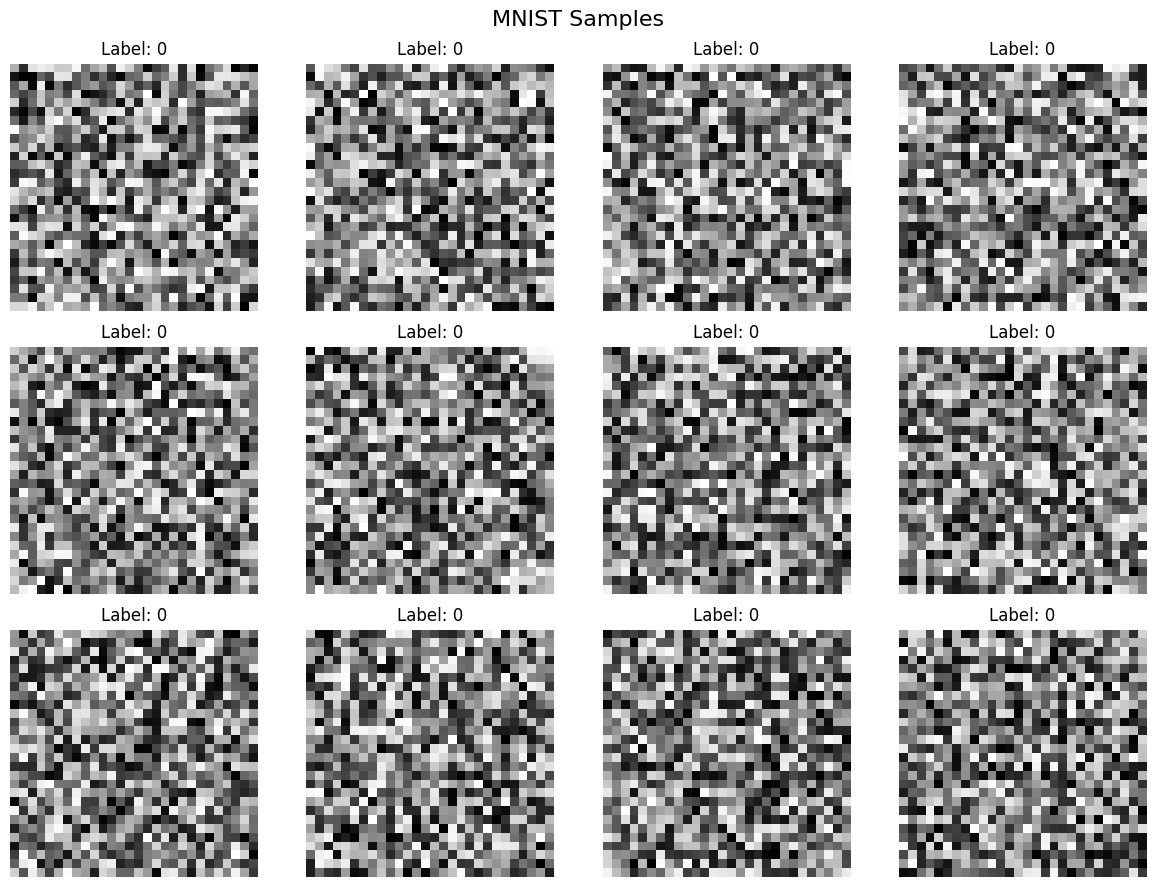

In [15]:
class CustomImageDataset(Dataset):
    """Custom dataset for loading images from a directory structure."""
    
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        
        self.samples = []
        self.labels = []
        
        # Generate synthetic image-like data
        for class_id in range(3):  # 3 classes
            for sample_id in range(50):  # 50 samples per class
                # Create random image-like data
                fake_image = torch.randint(0, 256, (28, 28), dtype=torch.uint8)
                self.samples.append(fake_image)
                self.labels.append(class_id)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image = self.samples[idx].float() / 255.0  # Normalize to [0, 1]
        label = self.labels[idx]
        
        if self.transform:
            # Convert to PIL for transforms compatibility
            image_pil = transforms.ToPILImage()(image)
            image = self.transform(image_pil)
        
        return image, label

# Create custom dataset
custom_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

custom_dataset = CustomImageDataset(data_dir="./fake_data", transform=custom_transform)
custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

print(f"Custom dataset size: {len(custom_dataset)}")
print(f"Number of batches: {len(custom_loader)}")

# Show sample
sample_img, sample_label = custom_dataset[0]
print(f"Sample shape: {sample_img.shape}, Label: {sample_label}")

visualize_samples(custom_dataset)

